In [ ]:
!pip install -q roboflow ultralytics opencv-python matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.7 MB/s eta 0:00:00


In [ ]:
import os
import yaml
from roboflow import Roboflow

# Initialize Roboflow
rf = Roboflow(api_key="Y7ZkdkpoRJdvjt4QsQod")
project = rf.workspace("meghana-x3ouv").project("twinsense-sleeper-crack-n0wvg-monii")
version = project.version(6)

# Download in OBB format
dataset = version.download("yolov8-obb")
dataset_dir = dataset.location

# Fix data.yaml paths for Ultralytics
with open(os.path.join(dataset_dir, "data.yaml"), 'r') as f:
    config = yaml.safe_load(f)

config['path'] = dataset_dir  # Set absolute path
with open(os.path.join(dataset_dir, "data.yaml"), 'w') as f:
    yaml.dump(config, f)

print(f"Dataset ready at: {dataset_dir}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Twinsense---sleeper-crack-6 in yolov8-obb:: 100%|██████████| 308/308 [00:00<00:00, 795.78it/s]

Dataset ready at: /content/Twinsense---sleeper-crack-6


In [ ]:
from ultralytics import YOLO

# Load the OBB-specific nano model
model = YOLO("yolov8s-obb.pt")

# Optimized training parameters
results = model.train(
    data=os.path.join(dataset_dir, "data.yaml"),
    epochs=150,           # Increased epochs for better convergence
    imgsz=1024,           # CRITICAL: High resolution for small crack details
    batch=8,              # Adjust based on your GPU memory (VRAM)
    patience=20,          # Early stopping if no improvement
    device=0,             # Use 'cpu' if no GPU available
    optimizer='AdamW',    # Better for complex features like cracks
    lr0=0.001,            # Stable initial learning rate
    augment=True,         # Enable heavy augmentation
    mosaic=1.0,           # Helps with small object detection
    project="sleeper_crack_project",
    name="obb_improved_run"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Twinsense---sleeper-crack-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 


image 1/1 /content/Twinsense---sleeper-crack-6/test/images/IMG-20250826-WA0013_jpg.rf.cf6e61b040c4b5397518f0c121a0aa1e.jpg: 1024x768 4 cracks under rail seats, 57.2ms
Speed: 4.4ms preprocess, 57.2ms inference, 2.4ms postprocess per image at shape (1, 3, 1024, 768)

image 1/1 /content/Twinsense---sleeper-crack-6/test/images/IM5715-1_JPG.rf.604c061942c02f9af29b4c6f4cda966f.jpg: 1024x768 1 cracks in midportion, 15.9ms
Speed: 4.2ms preprocess, 15.9ms inference, 2.4ms postprocess per image at shape (1, 3, 1024, 768)

image 1/1 /content/Twinsense---sleeper-crack-6/test/images/IMG-20250825-WA0035_jpg.rf.1e28ae2c154697f8becad23b4c96dd7b.jpg: 1024x768 1 cracks under rail seat, 15.9ms
Speed: 4.4ms preprocess, 15.9ms inference, 2.3ms postprocess per image at shape (1, 3, 1024, 768)

image 1/1 /content/Twinsense---sleeper-crack-6/test/images/IMG-20250826-WA0017_jpg.rf.85a4562eef5a7e36ca678a0b516c8fdd.jpg: 1024x768 10 cracks under rail seats, 15.9ms
Speed: 4.5ms preprocess, 15.9ms inference, 2.9ms

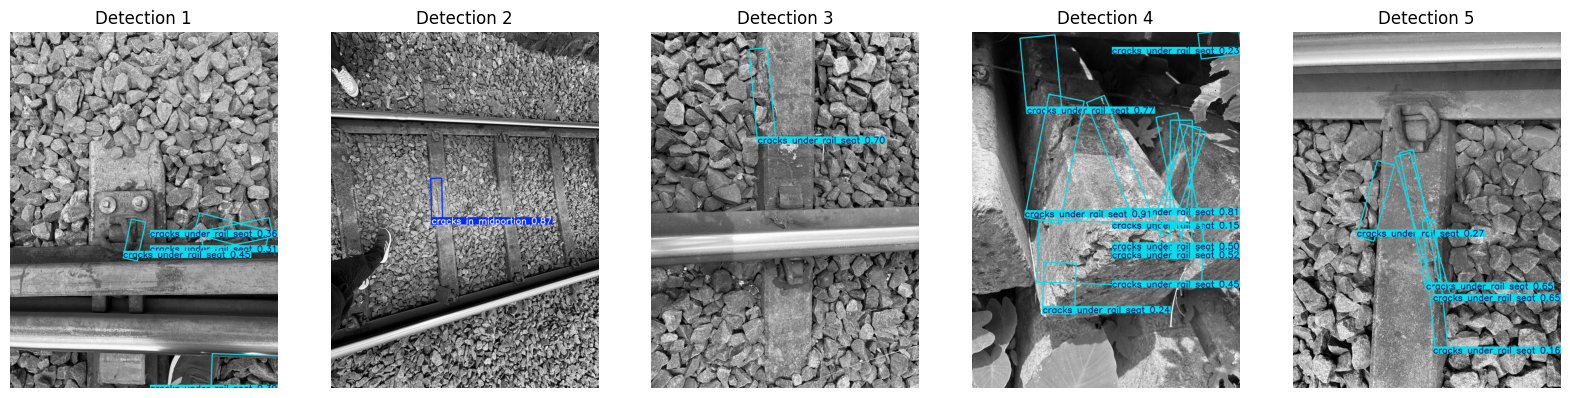

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Load your best trained model
best_model_path = "/content/runs/obb/sleeper_crack_project/obb_improved_run/weights/best.pt"
model = YOLO(best_model_path)

test_images = list(Path(dataset_dir).glob("test/images/*.jpg"))[:5] # Test first 5

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(test_images):
    # Run prediction with OBB support
    # We use a lower confidence to ensure the model "tries" to find the cracks
    results = model.predict(source=str(img_path), conf=0.15, imgsz=1024)

    # Use the built-in plot() for OBB visualization
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title(f"Detection {i+1}")

plt.show()

In [ ]:
from ultralytics import YOLO
import os

# Load the best trained model again
best_model_path = "/content/runs/obb/sleeper_crack_project/obb_improved_run/weights/best.pt"
model = YOLO(best_model_path)

# Run validation on the dataset to get the metrics
val_results = model.val(data=os.path.join(dataset_dir, "data.yaml"))

print("Validation Metrics:")
print(f"  mAP50: {val_results.box.map50:.3f}")
print(f"  mAP50-95: {val_results.box.map:.3f}")
print(f"  Precision: {val_results.box.p[0]:.3f}")
print(f"  Recall: {val_results.box.r[0]:.3f}")

Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-obb summary (fused): 82 layers, 11,412,732 parameters, 0 gradients, 29.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4504.6±1040.3 MB/s, size: 939.0 KB)
val: Scanning /content/Twinsense---sleeper-crack-6/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 6.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9s/it 1.9s
                   all         15         26      0.654      0.705      0.753       0.44
  cracks in midportion          8         10      0.615        0.4      0.613      0.271
cracks under rail seat          7         14      0.425      0.714      0.653      0.344
                damage          1          2      0.921          1      0.995      0.705
Speed: 2.2ms preprocess, 31.4ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /content/runs/